# How is $\bar{X} - \bar{Y}$ normally distributed if X and Y are normally distributed?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's create two random datasets first, we are going to apply CLT first.

In [2]:
x = np.random.randint(0, 20_000, 5000)
y = np.random.randint(20_000, 100_000, 2000)

In [3]:
x[:10], y[:10]

(array([ 3253,  6279, 17811, 18148,  4660,  9401,  7777,  8106,  1536,
         6783]),
 array([99901, 31473, 53381, 20551, 72711, 48935, 87096, 23430, 97501,
        97309]))

Our first dataset consists of 5000 integer data points, between 0 and 20.000. And our second dataset consists of 2000 integer data points, between 20.000 and 100.000. They are non-overlapping on purpose, and the purpose is to see the wanted reuslt clearer.

In [4]:
means_x = np.array(
    [np.mean(np.random.choice(x, size=30, replace=False)) for i in range(5000)]
)
means_y = np.array(
    [np.mean(np.random.choice(y, size=30, replace=False)) for i in range(5000)]
)

We sampled 5000 times from each dataset, and the sample size is 30 for the both.

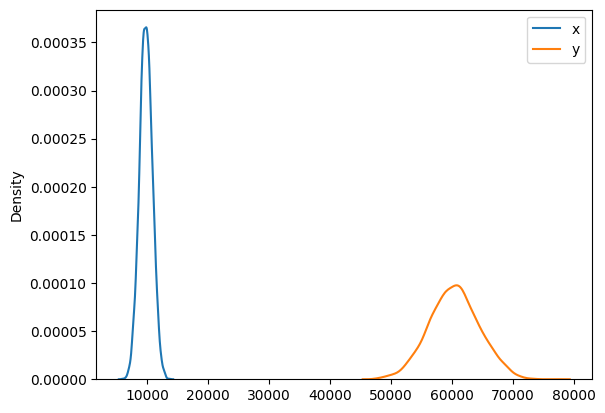

In [5]:
fig, ax = plt.subplots()
sns.kdeplot(means_x, ax=ax, label="x")
sns.kdeplot(means_y, ax=ax, label="y")
ax.legend()
plt.show()

Because of CLT, we have a two normally distributed data. And the means and the standard deviations are different.

In [6]:
means_minus = means_x - means_y

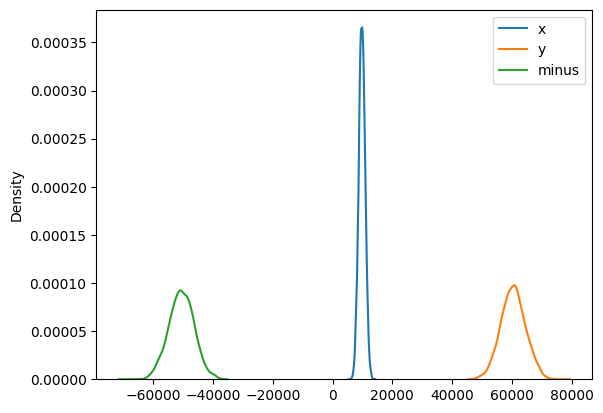

In [7]:
fig, ax = plt.subplots()
sns.kdeplot(means_x, ax=ax, label="x")
sns.kdeplot(means_y, ax=ax, label="y")
sns.kdeplot(means_minus, ax=ax, label="minus")
ax.legend()
plt.show()

Statistical notation of `means_minus = means_x - means_y` is $\bar{X} - \bar{Y}$. And as you can see, `means_minus` is also normally distributed.

We know that:

- $Var\[\bar{X} - \bar{Y}\] = Var\[\bar{X}\] + Var\[\bar{Y}\]$ 
- $E\[\bar{X} - \bar{Y}\] = E\[\bar{X}\] - E\[\bar{Y}\]$ 

Let's prove it.

In [8]:
mean_means_x = np.mean(means_x)
mean_means_y = np.mean(means_y)
var_means_x = np.var(means_x)
var_means_y = np.var(means_y)

In [9]:
np.mean(means_minus), mean_means_x - mean_means_y

(np.float64(-50587.711306666664), np.float64(-50587.71130666667))

In [10]:
np.var(means_minus), var_means_x + var_means_y

(np.float64(17779222.304161493), np.float64(17979413.193620276))

Yes, it is indeed correct.

**TODO:** Mathematically prove the below conclusions:

- $Var\[\bar{X} - \bar{Y}\] = Var\[\bar{X}\] + Var\[\bar{Y}\]$ 
- $E\[\bar{X} - \bar{Y}\] = E\[\bar{X}\] - E\[\bar{Y}\]$ 

**TODO:** Why do we need X and Y to be normally distributed, doesn't CLT already do that for us?